# Part 1: Analyse the Network

### Introduction to the network

The rock performers network is a directed graph of 484 mainstream rock artists constructed from Wikipedia, where edges represent hyperlinks between artist pages. In-degree reflects an artist's prominence (how often they are referenced), while out-degree reflects their page's comprehensiveness. We analyze this network using centrality measures, community detection, assortativity, and backbone extraction to understand the structure and key players within the rock music landscape.

### Basic Properties & Degree Analysis:

In [ ]:
import networkx as nx
import requests
import matplotlib.pyplot as plt
import numpy as np
from io import BytesIO

# Download and load the network directly from GitHub like assignment 1.2
url = "https://raw.githubusercontent.com/Pakkutaq/SG_rock_network/main/rock_artists/rock_network.graphml"
response = requests.get(url)

G = nx.read_graphml(BytesIO(response.content))

We begin by examining the fundamental structural properties of the rock performers network. With 484 nodes and 7,267 edges, the network has a density of 0.0311, indicating a sparse network where only about 3% of all possible connections exist. The average clustering coefficient is 0.2338, suggesting moderate local clustering where artists who share connections tend to be connected to each other.

The scatter plot in Figure X shows the relationship between in-degree (how often artists are cited) and out-degree (how many artists they cite), with a correlation of 0.5831. Most artists cluster in the lower-left region with both low in-degree and out-degree. However, highly referenced artists (high in-degree) often have moderate out-degree, while some less famous artists have very high out-degree (60-74 links). This indicates that being frequently cited doesn't necessarily mean an artist's Wikipedia page extensively references others - fame and citation behavior are partially independent.

Network density: 0.0311
Average clustering coefficient: 0.2338


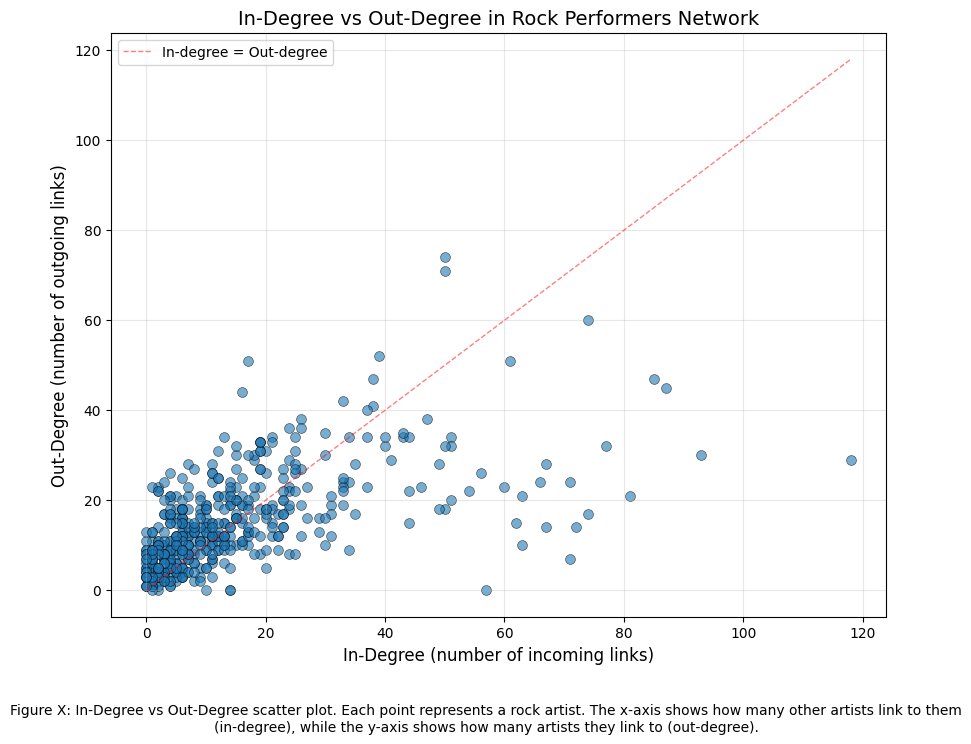


Correlation between in-degree and out-degree: 0.5831


In [ ]:
# Calculate density
density = nx.density(G)
print(f"Network density: {density:.4f}")

# Calculate clustering coefficient
avg_clustering = nx.average_clustering(G.to_undirected())
print(f"Average clustering coefficient: {avg_clustering:.4f}")

# Get in-degrees and out-degrees for all nodes
in_degrees = [G.in_degree(node) for node in G.nodes()]
out_degrees = [G.out_degree(node) for node in G.nodes()]

# Create scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(in_degrees, out_degrees, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.xlabel('In-Degree (number of incoming links)', fontsize=12)
plt.ylabel('Out-Degree (number of outgoing links)', fontsize=12)
plt.title('In-Degree vs Out-Degree in Rock Performers Network', fontsize=14)
plt.grid(True, alpha=0.3)

# Add a reference line (y=x) to show where in-degree equals out-degree
max_degree = max(max(in_degrees), max(out_degrees))
plt.plot([0, max_degree], [0, max_degree], 'r--', alpha=0.5, linewidth=1, label='In-degree = Out-degree')
plt.legend()

plt.figtext(0.5, 0.01, "Figure X: In-Degree vs Out-Degree scatter plot. Each point represents a rock artist. " \
            "The x-axis shows how many other artists link to them (in-degree), while the y-axis shows how many artists they link to (out-degree).", 
            ha="center", fontsize=10, wrap=True)
plt.subplots_adjust(bottom=0.15)
plt.show()

# Calculate correlation between in-degree and out-degree
correlation = np.corrcoef(in_degrees, out_degrees)[0, 1]
print(f"\nCorrelation between in-degree and out-degree: {correlation:.4f}")

### Backbone analysis

The full network with 7,267 edges is too dense to easily identify the most important structural patterns. To reveal the core relationships between rock artists, we first create a weighted version of the network where edge weights are proportional to edge betweenness centrality - edges that lie on many shortest paths between artists receive higher weights. We normalize these weights so the minimum is 1 and the maximum is 100. We then extract a network backbone using the disparity filter with a significance level of α = 0.05, which identifies edges that carry disproportionately more weight in a node's connectivity pattern.

Calculating edge betweenness centrality...
This may take a few minutes for a network of this size...
Created weighted network with edge weights in range [1, 100]

Applying disparity filter (α = 0.1)...

Backbone Statistics:
  Nodes: 368 (76.0% of original)
  Edges: 393 (6.6% of original)
  Density: 0.0058 (original: 0.0513)


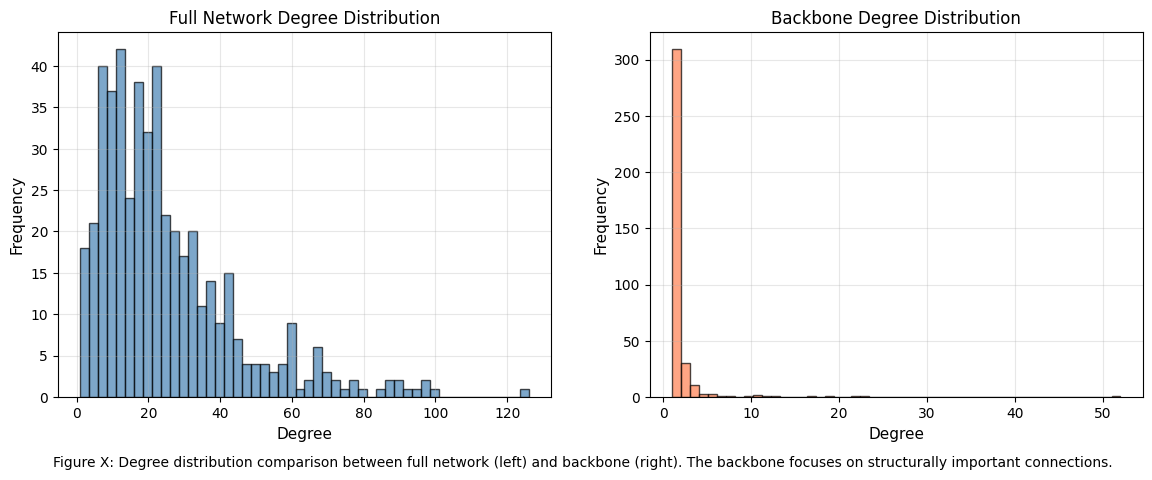

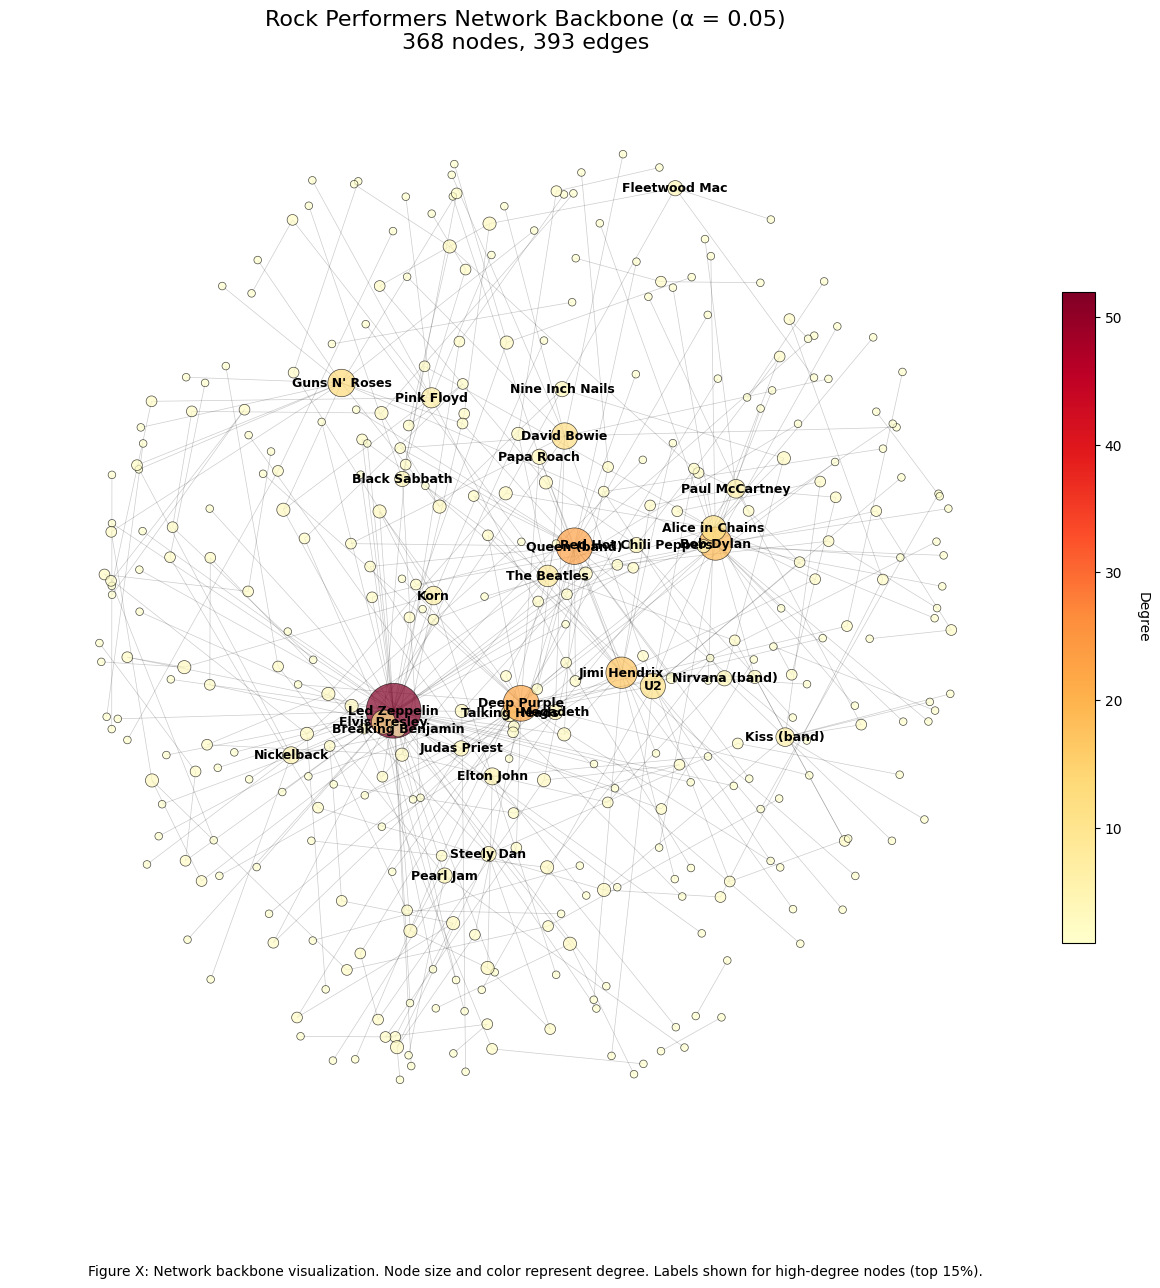

In [ ]:
# Step 1: Convert to undirected (if not already)
G_undirected = G.to_undirected()

print("Calculating edge betweenness centrality...")
print("This may take a few minutes for a network of this size...")

# Step 2: Calculate edge betweenness centrality
edge_betweenness = nx.edge_betweenness_centrality(G_undirected)

# Step 3: Normalize edge betweenness to range [1, 100]
min_betweenness = min(edge_betweenness.values())
max_betweenness = max(edge_betweenness.values())

# Create weighted network
G_weighted = G_undirected.copy()

for edge, betweenness in edge_betweenness.items():
    # Normalize to [1, 100]
    normalized_weight = 1 + 99 * (betweenness - min_betweenness) / (max_betweenness - min_betweenness)
    G_weighted[edge[0]][edge[1]]['weight'] = normalized_weight

print(f"Created weighted network with edge weights in range [1, 100]")

# Step 4: Apply disparity filter
def disparity_filter(G, alpha=0.05):
    """
    Apply disparity filter to extract network backbone.
    
    For each node, the disparity filter tests whether each edge weight
    is significantly larger than expected under a null model.
    """
    B = nx.Graph()
    B.add_nodes_from(G.nodes(data=True))
    
    for node in G.nodes():
        edges = list(G.edges(node, data=True))
        
        if len(edges) == 0:
            continue
            
        k = len(edges)  # degree
        s = sum(d.get('weight', 1) for u, v, d in edges)  # total strength
        
        for u, v, data in edges:
            weight = data.get('weight', 1)
            
            if s > 0:
                # Disparity filter p-value
                p_value = (1 - weight / s) ** (k - 1)
                
                if p_value < alpha:
                    if not B.has_edge(u, v):
                        B.add_edge(u, v, weight=weight, p_value=p_value)
    
    return B

print("\nApplying disparity filter (α = 0.1)...")
backbone = disparity_filter(G_weighted, alpha=0.135)

# Remove isolated nodes
isolated = [node for node in backbone.nodes() if backbone.degree(node) == 0]
backbone.remove_nodes_from(isolated)

# Step 5: Report statistics
print(f"\nBackbone Statistics:")
print(f"  Nodes: {backbone.number_of_nodes()} ({100*backbone.number_of_nodes()/G.number_of_nodes():.1f}% of original)")
print(f"  Edges: {backbone.number_of_edges()} ({100*backbone.number_of_edges()/G_undirected.number_of_edges():.1f}% of original)")
print(f"  Density: {nx.density(backbone):.4f} (original: {nx.density(G_undirected):.4f})")

# Step 6: Compare degree distributions
G_degrees = [d for n, d in G_undirected.degree()]
backbone_degrees = [d for n, d in backbone.degree()]

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Full network degree distribution
axs[0].hist(G_degrees, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axs[0].set_xlabel('Degree', fontsize=11)
axs[0].set_ylabel('Frequency', fontsize=11)
axs[0].set_title('Full Network Degree Distribution')
axs[0].grid(True, alpha=0.3)

# Backbone degree distribution
axs[1].hist(backbone_degrees, bins=50, edgecolor='black', alpha=0.7, color='coral')
axs[1].set_xlabel('Degree', fontsize=11)
axs[1].set_ylabel('Frequency', fontsize=11)
axs[1].set_title('Backbone Degree Distribution')
axs[1].grid(True, alpha=0.3)

plt.figtext(0.5, 0.01, "Figure X: Degree distribution comparison between full network (left) and backbone (right). " \
            "The backbone focuses on structurally important connections.",
            ha="center", fontsize=10, wrap=True)
plt.subplots_adjust(bottom=0.15)
plt.show()

# Step 7: Visualize the backbone
plt.figure(figsize=(14, 14))

pos = nx.spring_layout(backbone, k=1.0, iterations=50, seed=42)

# Node sizes and colors based on degree in backbone
node_sizes = [backbone.degree(node) * 30 for node in backbone.nodes()]
node_colors = [backbone.degree(node) for node in backbone.nodes()]

# Draw
nx.draw_networkx_nodes(backbone, pos, node_size=node_sizes, node_color=node_colors,
                       cmap=plt.cm.YlOrRd, alpha=0.7, edgecolors='black', linewidths=0.5)
nx.draw_networkx_edges(backbone, pos, alpha=0.2, width=0.5)

# Label high-degree nodes
high_degree_nodes = [node for node in backbone.nodes() 
                     if backbone.degree(node) > np.percentile(backbone_degrees, 85)]
labels = {node: node for node in high_degree_nodes}
nx.draw_networkx_labels(backbone, pos, labels, font_size=9, font_weight='bold')

plt.title(f'Rock Performers Network Backbone (α = 0.05)\n{backbone.number_of_nodes()} nodes, {backbone.number_of_edges()} edges',
          fontsize=16)
plt.axis('off')

sm = plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd, 
                           norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.03, pad=0.02)
cbar.set_label('Degree', rotation=270, labelpad=20)

plt.figtext(0.5, 0.01, "Figure X: Network backbone visualization. Node size and color represent degree. " \
            "Labels shown for high-degree nodes (top 15%).",
            ha="center", fontsize=10, wrap=True)
plt.subplots_adjust(bottom=0.08)
plt.show()